In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

In [2]:
citas = pd.read_csv("Analisis GAC Full7agosto 2026(Citas Digital).csv", low_memory=False)
print("Filas y columnas:", citas.shape)

Filas y columnas: (1048575, 16)


In [3]:
citas = citas[citas["Nombre Cliente "].notna()].copy()
print("Filas reales:", citas.shape)
citas.head()

Filas reales: (668, 16)


,BDC,Fecha,Nombre Cliente,Telefono,Estatus de Lead,Potencial de compra,PDM,SDC,Venta,Asesor Asignado,¿Por que no ha visitado la agencia?,¿Por que no hay solicitud de credito?,¿Por que no hubo prueba de manejo ?,¿Por que no hubo proceso wow?,¿Por que se asigno antes de vistar piso?,Unnamed: 15
0,Saul,NaN,Guillermo,NaN,Finalizado,90%,TRUE,False,False,Nancy,"Ya visito la Agencia el dia jueves 17, intere...","Pide arrendamiento, unicamente se esta en espe...","Si, hizo prueba de manejo","Si recibio procesos wow, estuvo en la agencia ...","No, se espero a que visitara la agencia para s...",Comenta que no se le hizo atractivo el arrenda...
1,Saul,NaN,Roberto,NaN,Finalizado,40%,FALSE,False,False,Victor,Ya visito la Agencia el dia 3 de abril,Por que primero queria manejar las unidad,No habia unidad GS8 HEV para prueba de manejo,"Si recibio procesos wow, sin embargo no quizo ...",Se asigno hasta que visitara Piso,NaN
2,Saul,NaN,Irving,NaN,Finalizado,85%,FALSE,False,False,Alan,Ya visito la agencia el dia 21 de abril,"Firmo solicitud, sin embargo despues comento q...",Por que no habia unidad para prueba de manejo,"Si se realizo el proceso wow, los clientes se ...",Se asigno hasta que visitara Piso,Se le manda msj de seguimiento 03/05/2025
3,Saul,NaN,Oswaldo,NaN,Venta,90%,FALSE,False,True,Mauricio,El cliente vive en Tabasco Villahermosa,Sera compra de contado,"Ya la manejo en Villahermosa, sin embargo por ...","Las veces que se le ha marcado, agradece mucho...","Necesitabamos sacar el apartado, por eso se as...",NaN
4,Saul,NaN,Rodrigo,NaN,Finalizado,90%,TRUE,False,False,Mauricio,"Visito la agencia el mes pasado, y nos visita ...",Hoy visita nuevamente la agencia y se firma so...,"La primera vez que nos visito, realizo PDM",Si recibio el proceso wow la primera vez que n...,Se asigno hasta que visitara Piso la primera ...,Por el detalle del carbilink compro en otra ma...


In [4]:
citas = citas[["Potencial de compra", "PDM", "SDC", "Venta"]].copy()

# Potencial de compra: quito simbolos raros y lo paso a numero
texto = citas["Potencial de compra"].astype(str).str.strip()
for simbolo in ["%", "&", "'", " "]:
    texto = texto.str.replace(simbolo, "", regex=False)
citas["Potencial de compra"] = pd.to_numeric(texto, errors="coerce")

# PDM, SDC y Venta: TRUE = 1, FALSE = 0
for col in ["PDM", "SDC", "Venta"]:
    citas[col] = citas[col].astype(str).str.strip().str.upper().map({"TRUE": 1, "FALSE": 0})

print(citas.dtypes)
citas.head()

Potencial de compra    float64
PDM                    float64
SDC                    float64
Venta                  float64
dtype: object


,Potencial de compra,PDM,SDC,Venta
0,90.0,1.0,0.0,0.0
1,40.0,0.0,0.0,0.0
2,85.0,0.0,0.0,0.0
3,90.0,0.0,0.0,1.0
4,90.0,1.0,0.0,0.0


### Nulos

In [5]:
print("Nulos por columna:")
print(citas.isnull().sum())

# Quito las filas que quedaron con algun nulo
citas = citas.dropna().reset_index(drop=True)
print("\nFilas despues de quitar nulos:", len(citas))

Nulos por columna:
Potencial de compra    55
PDM                     1
SDC                     1
Venta                   4
dtype: int64

Filas despues de quitar nulos: 610


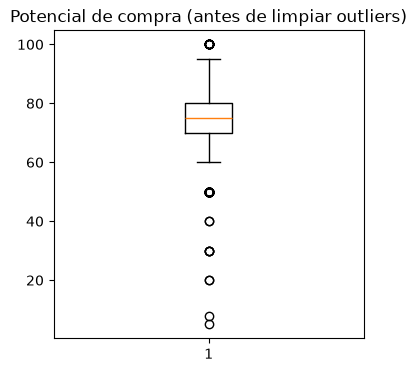

Limite bajo: 55.0  Limite alto: 95.0
Outliers encontrados: 74
Filas finales base 1: 536


In [6]:
plt.figure(figsize=(4, 4))
plt.boxplot(citas["Potencial de compra"])
plt.title("Potencial de compra (antes de limpiar outliers)")
plt.show()

q1 = citas["Potencial de compra"].quantile(0.25)
q3 = citas["Potencial de compra"].quantile(0.75)
iqr = q3 - q1
limite_bajo = q1 - 1.5 * iqr
limite_alto = q3 + 1.5 * iqr
print("Limite bajo:", limite_bajo, " Limite alto:", limite_alto)

es_outlier = (citas["Potencial de compra"] < limite_bajo) | (citas["Potencial de compra"] > limite_alto)
print("Outliers encontrados:", es_outlier.sum())

citas = citas[~es_outlier].reset_index(drop=True)
print("Filas finales base 1:", len(citas))

                     Potencial de compra   PDM   SDC  Venta
Potencial de compra                 1.00  0.20  0.18   0.24
PDM                                 0.20  1.00  0.07   0.17
SDC                                 0.18  0.07  1.00   0.23
Venta                               0.24  0.17  0.23   1.00


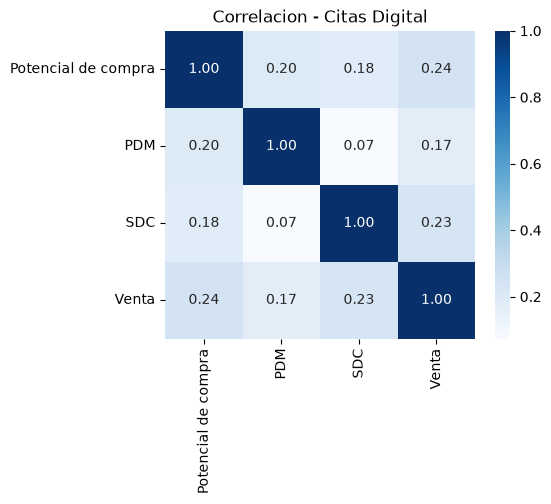

In [7]:
correlacion = citas.corr()
print(correlacion.round(2))

plt.figure(figsize=(5, 4))
sns.heatmap(correlacion, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlacion - Citas Digital")
plt.show()

Pendiente (m): 0.00797
Interseccion (b): -0.5178
r  (correlacion): 0.245
r2 (que tanto explica): 0.06
valor p: 0.0


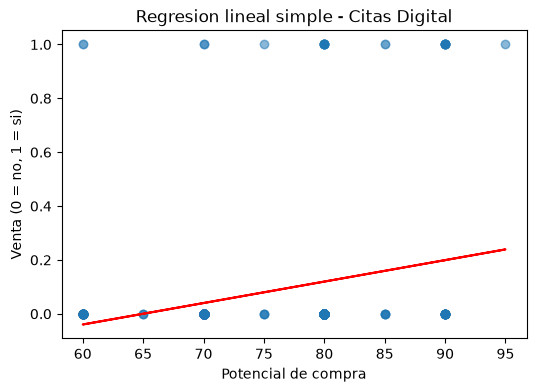

In [8]:
x = citas["Potencial de compra"]
y = citas["Venta"]

modelo = linregress(x, y)
print("Pendiente (m):", round(modelo.slope, 5))
print("Interseccion (b):", round(modelo.intercept, 4))
print("r  (correlacion):", round(modelo.rvalue, 3))
print("r2 (que tanto explica):", round(modelo.rvalue ** 2, 3))
print("valor p:", round(modelo.pvalue, 5))

plt.figure(figsize=(6, 4))
plt.scatter(x, y, alpha=0.3)
plt.plot(x, modelo.intercept + modelo.slope * x, color="red")
plt.xlabel("Potencial de compra")
plt.ylabel("Venta (0 = no, 1 = si)")
plt.title("Regresion lineal simple - Citas Digital")
plt.show()

In [9]:
crudo = pd.read_csv("Analisis GAC Full7agosto 2026(Analisis de Piso ).csv",
                    header=None, low_memory=False)

piso = pd.DataFrame({
    "Asesor": crudo[0],
    "Leads_Prom_Mes": crudo[37],
    "Ventas_Piso": crudo[38],
    "Ventas_Historicas": crudo[40],
    "PDM": crudo[43],
    "SDC": crudo[44],
    "Conversion_PDM": crudo[45],
    "Conversion_SDC": crudo[46],
})

# La tabla de asesores empieza en la fila 4
piso = piso.iloc[4:].reset_index(drop=True)
piso = piso[piso["Asesor"].notna()].copy()
print("Filas (asesores):", len(piso))
piso.head()

Filas (asesores): 40


,Asesor,Leads_Prom_Mes,Ventas_Piso,Ventas_Historicas,PDM,SDC,Conversion_PDM,Conversion_SDC
0,ABIGAIL,0,0,1,1,5,100%,0%
1,ALAN GONZALES,10,11,18,59,40,31%,2%
2,ALICIA LEDESMA,0,0,NaN,1,1,0%,0%
3,AURELIO FELIPE,8,3,8,28,31,29%,1%
4,CARLOS ALBERTO NIETO,7,9,15,64,30,23%,2%


### Pasar las columnas a numero

In [10]:
# Columnas que ya son numeros pero venian como texto
for col in ["Leads_Prom_Mes", "Ventas_Piso", "Ventas_Historicas", "PDM", "SDC"]:
    piso[col] = pd.to_numeric(piso[col], errors="coerce")

# Las conversiones vienen con "%" (y a veces con errores tipo #DIV/0!)
for col in ["Conversion_PDM", "Conversion_SDC"]:
    sin_signo = piso[col].astype(str).str.replace("%", "", regex=False)
    piso[col] = pd.to_numeric(sin_signo, errors="coerce")

print(piso.dtypes)

Asesor                   str
Leads_Prom_Mes         int64
Ventas_Piso            int64
Ventas_Historicas    float64
PDM                    int64
SDC                  float64
Conversion_PDM       float64
Conversion_SDC       float64
dtype: object


### Nulos

In [11]:
print("Nulos por columna:")
print(piso.isnull().sum())

# Si un asesor no tiene historial o conversion, lo tomo como 0
piso["Ventas_Historicas"] = piso["Ventas_Historicas"].fillna(0)
piso["Conversion_PDM"] = piso["Conversion_PDM"].fillna(0)
piso["Conversion_SDC"] = piso["Conversion_SDC"].fillna(0)

# Si falta el dato clave (ventas o pruebas de manejo) quito la fila
piso = piso.dropna(subset=["Ventas_Piso", "PDM", "SDC"]).reset_index(drop=True)
print("\nFilas despues de nulos:", len(piso))

Nulos por columna:
Asesor                0
Leads_Prom_Mes        0
Ventas_Piso           0
Ventas_Historicas    14
PDM                   0
SDC                   1
Conversion_PDM        2
Conversion_SDC        1
dtype: int64

Filas despues de nulos: 39


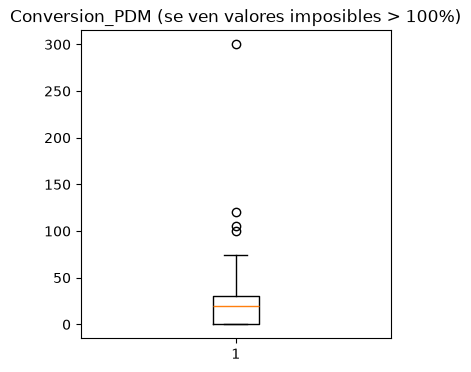

Filas con conversion imposible: 3
                  Asesor  Conversion_PDM
9                   CASA           105.0
20    JOSE MANUEL  LOPEZ           300.0
34  PAUL  ROSAS IRIGOYIN           120.0

Filas finales base 2: 36


In [12]:
plt.figure(figsize=(4, 4))
plt.boxplot(piso["Conversion_PDM"])
plt.title("Conversion_PDM (se ven valores imposibles > 100%)")
plt.show()

error_captura = piso["Conversion_PDM"] > 100
print("Filas con conversion imposible:", error_captura.sum())
print(piso.loc[error_captura, ["Asesor", "Conversion_PDM"]])

piso = piso[~error_captura].reset_index(drop=True)
print("\nFilas finales base 2:", len(piso))

                   Leads_Prom_Mes  Ventas_Piso  Ventas_Historicas   PDM   SDC  \
Leads_Prom_Mes               1.00         0.77               0.59  0.74  0.54   
Ventas_Piso                  0.77         1.00               0.83  0.89  0.70   
Ventas_Historicas            0.59         0.83               1.00  0.86  0.89   
PDM                          0.74         0.89               0.86  1.00  0.83   
SDC                          0.54         0.70               0.89  0.83  1.00   
Conversion_PDM               0.13         0.24               0.50  0.22  0.41   
Conversion_SDC               0.07        -0.05              -0.10 -0.12 -0.18   

                   Conversion_PDM  Conversion_SDC  
Leads_Prom_Mes               0.13            0.07  
Ventas_Piso                  0.24           -0.05  
Ventas_Historicas            0.50           -0.10  
PDM                          0.22           -0.12  
SDC                          0.41           -0.18  
Conversion_PDM               1.00      

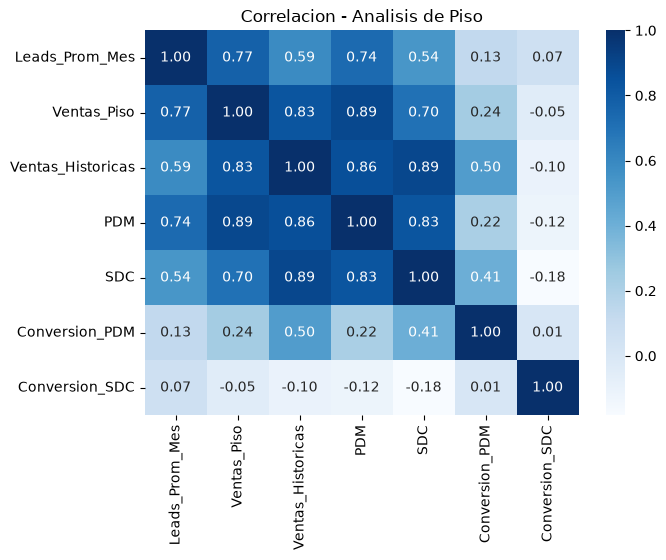

In [13]:
columnas_num = ["Leads_Prom_Mes", "Ventas_Piso", "Ventas_Historicas",
                "PDM", "SDC", "Conversion_PDM", "Conversion_SDC"]
correlacion2 = piso[columnas_num].corr()
print(correlacion2.round(2))

plt.figure(figsize=(7, 5))
sns.heatmap(correlacion2, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlacion - Analisis de Piso")
plt.show()

Pendiente (m): 0.1318
Interseccion (b): -0.7107
r  (correlacion): 0.89
r2 (que tanto explica): 0.793
valor p: 0.0


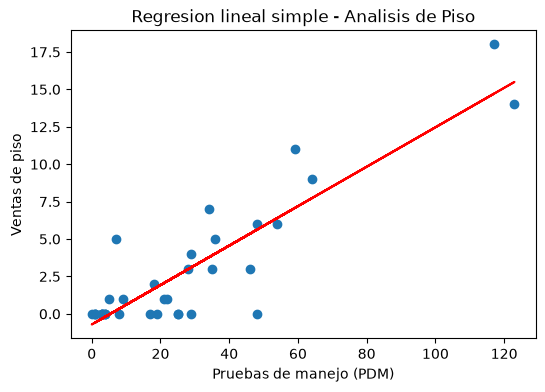

In [14]:
x2 = piso["PDM"]
y2 = piso["Ventas_Piso"]

modelo2 = linregress(x2, y2)
print("Pendiente (m):", round(modelo2.slope, 4))
print("Interseccion (b):", round(modelo2.intercept, 4))
print("r  (correlacion):", round(modelo2.rvalue, 3))
print("r2 (que tanto explica):", round(modelo2.rvalue ** 2, 3))
print("valor p:", round(modelo2.pvalue, 6))

plt.figure(figsize=(6, 4))
plt.scatter(x2, y2)
plt.plot(x2, modelo2.intercept + modelo2.slope * x2, color="red")
plt.xlabel("Pruebas de manejo (PDM)")
plt.ylabel("Ventas de piso")
plt.title("Regresion lineal simple - Analisis de Piso")
plt.show()

## Base 3: Ventas por Asesor

In [15]:
crudo3 = pd.read_csv("Analisis GAC Full7agosto 2026(Ventas por Asesor ).csv",
                     header=None, low_memory=False)

# Los meses van en las columnas 1 a 30 (Feb-24 ... Jul-26).
# El acumulado esta en la 31 (total), 33 (2024), 35 (2025) y 37 (2026).
# La lista de vendedores empieza en la fila 5 y termina antes de "Total general".
meses = list(range(1, 31))

ventas = pd.DataFrame({
    "Asesor": crudo3[0],
    "Ventas_Totales": crudo3[31],
    "Ventas_2024": crudo3[33],
    "Ventas_2025": crudo3[35],
    "Ventas_2026": crudo3[37],
})

# Cuento en cuantos meses el asesor vendio al menos un auto
matriz_meses = crudo3[meses].apply(pd.to_numeric, errors="coerce")
ventas["Meses_Activos"] = (matriz_meses.fillna(0) > 0).sum(axis=1)

ventas = ventas.iloc[5:].reset_index(drop=True)
ventas = ventas[ventas["Asesor"].notna()].copy()
ventas = ventas[ventas["Asesor"].astype(str).str.strip() != "Total general"].copy()
print("Filas (asesores):", len(ventas))
ventas.head()

Filas (asesores): 85


,Asesor,Ventas_Totales,Ventas_2024,Ventas_2025,Ventas_2026,Meses_Activos
0,PEDRO GONZALEZ ESPINDOLA,88,22,45,21,26
1,VICTOR MANUEL SANCHEZ ARRO,88,11,51,26,25
2,MIGUEL ANGEL SONDEREGGER,28,27,1,0,9
3,JOSE ANTONIO LICONA MENDE,98,10,35,53,25
4,JAIME GONZALEZ CORONA,25,25,0,0,8


### Pasar las columnas a numero

In [16]:
for col in ["Ventas_Totales", "Ventas_2024", "Ventas_2025", "Ventas_2026"]:
    ventas[col] = pd.to_numeric(ventas[col], errors="coerce")

print(ventas.dtypes)

Asesor                str
Ventas_Totales    float64
Ventas_2024       float64
Ventas_2025       float64
Ventas_2026       float64
Meses_Activos       int64
dtype: object


### Nulos

In [17]:
print("Nulos por columna:")
print(ventas.isnull().sum())

# Si no hay nombre de asesor o no hay ventas totales la fila no sirve
ventas = ventas.dropna(subset=["Ventas_Totales", "Meses_Activos"]).reset_index(drop=True)
print("\nFilas despues de quitar nulos:", len(ventas))

Nulos por columna:
Asesor             0
Ventas_Totales    34
Ventas_2024       34
Ventas_2025       34
Ventas_2026       34
Meses_Activos      0
dtype: int64

Filas despues de quitar nulos: 51


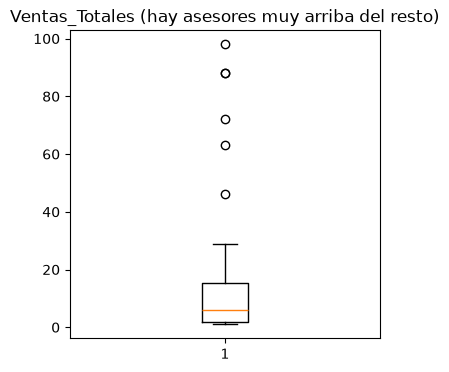

Limite alto: 35.75
Asesores marcados como outlier: 6
                       Asesor  Ventas_Totales  Meses_Activos
0    PEDRO GONZALEZ ESPINDOLA            88.0             26
1  VICTOR MANUEL SANCHEZ ARRO            88.0             25
3   JOSE ANTONIO LICONA MENDE            98.0             25
5   ALAN GONZÁLEZ BELANZATEGU            46.0             17
6  MAURICIO ALFREDO VAZQUEZ F            72.0             18
7   AURELIO FELIPE TORRES REV            63.0             18

Filas finales base 3: 51


In [18]:
plt.figure(figsize=(4, 4))
plt.boxplot(ventas["Ventas_Totales"])
plt.title("Ventas_Totales (hay asesores muy arriba del resto)")
plt.show()

q1 = ventas["Ventas_Totales"].quantile(0.25)
q3 = ventas["Ventas_Totales"].quantile(0.75)
iqr = q3 - q1
limite_alto = q3 + 1.5 * iqr
es_outlier = ventas["Ventas_Totales"] > limite_alto
print("Limite alto:", limite_alto)
print("Asesores marcados como outlier:", es_outlier.sum())
print(ventas.loc[es_outlier, ["Asesor", "Ventas_Totales", "Meses_Activos"]])

# Aqui NO los quito. En la base 1 los outliers eran errores de captura (80%%),
# pero estos son los mejores vendedores y son datos reales que si me interesan.
print("\nFilas finales base 3:", len(ventas))

                Meses_Activos  Ventas_Totales  Ventas_2024  Ventas_2025  \
Meses_Activos            1.00            0.97         0.44         0.92   
Ventas_Totales           0.97            1.00         0.46         0.92   
Ventas_2024              0.44            0.46         1.00         0.22   
Ventas_2025              0.92            0.92         0.22         1.00   
Ventas_2026              0.81            0.86         0.17         0.72   

                Ventas_2026  
Meses_Activos          0.81  
Ventas_Totales         0.86  
Ventas_2024            0.17  
Ventas_2025            0.72  
Ventas_2026            1.00  


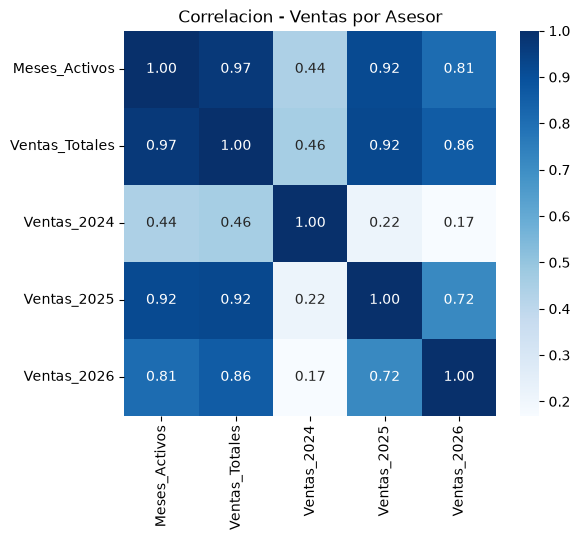

In [19]:
columnas_num = ["Meses_Activos", "Ventas_Totales",
                "Ventas_2024", "Ventas_2025", "Ventas_2026"]
correlacion3 = ventas[columnas_num].corr()
print(correlacion3.round(2))

plt.figure(figsize=(6, 5))
sns.heatmap(correlacion3, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlacion - Ventas por Asesor")
plt.show()

Pendiente (m): 3.519
Interseccion (b): -4.7293
r  (correlacion): 0.97
r2 (que tanto explica): 0.942
valor p: 0.0


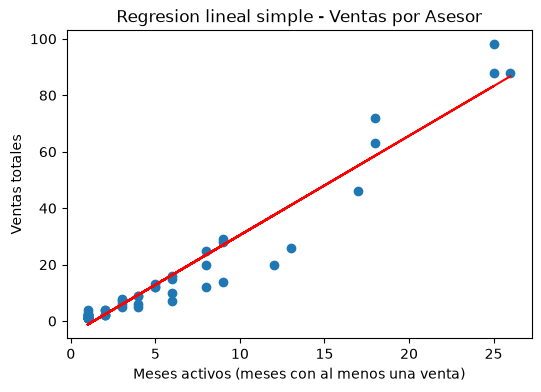

In [20]:
x3 = ventas["Meses_Activos"]
y3 = ventas["Ventas_Totales"]

modelo3 = linregress(x3, y3)
print("Pendiente (m):", round(modelo3.slope, 4))
print("Interseccion (b):", round(modelo3.intercept, 4))
print("r  (correlacion):", round(modelo3.rvalue, 3))
print("r2 (que tanto explica):", round(modelo3.rvalue ** 2, 3))
print("valor p:", round(modelo3.pvalue, 6))

plt.figure(figsize=(6, 4))
plt.scatter(x3, y3)
plt.plot(x3, modelo3.intercept + modelo3.slope * x3, color="red")
plt.xlabel("Meses activos (meses con al menos una venta)")
plt.ylabel("Ventas totales")
plt.title("Regresion lineal simple - Ventas por Asesor")
plt.show()